# Class 03: Multicollinearity and overfitting

*AI4AS — Pitfalls in Machine Learning (solution notebook)*

*Does multicollinearity lead to overfitting?*


## Introduction

This notebook uses the Ames Housing dataset to study **multicollinearity** and **overfitting**. Multicollinearity means that two or more input variables contain almost the same information. This can make a linear model difficult to interpret, even when its predictions still look reasonable.

The central question is: does multicollinearity always make prediction worse? You will see that the answer is more nuanced. It often hurts interpretation first. Prediction can still work if the test data have the same structure as the training data. Prediction becomes much harder when we move to an extrapolation set, or when we add many noisy correlated features.

Please work through the notebook **in order**. The numbered headings show the structure. Light-blue boxes are tasks. Amber boxes explain how to read the output.

### Official documentation

When you are unsure about a function, start with the official documentation.

| Library | Where to look |
|---------|----------------|
| **scikit-learn** | [User guide](https://scikit-learn.org/stable/user_guide.html) and [API reference](https://scikit-learn.org/stable/api/index.html) |
| **pandas** | [User guide](https://pandas.pydata.org/docs/user_guide/index.html) |
| **matplotlib** | [Tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| **seaborn** | [API reference](https://seaborn.pydata.org/api.html) |
| **imbalanced-learn** | [Documentation](https://imbalanced-learn.org/stable/) |

## Table of contents

1. **Setup**: Ames housing data
2. **Correlation**: `2.1`
3. **Multicollinearity**: redundancy `3.1`, exploratory data analysis `3.2`
4. **Training diagnostics**: VIF `4.1`, Ridge demonstration, reduced model `4.2` (advanced)
5. **Test sets**: standard vs extrapolation `5.1` (advanced)
6. **Lasso regularisation**: `6.1` and synthetic-feature extension


### Sources

Parts of this practical were adapted from the following resources:

- [Detecting and overcoming perfect multicollinearity in large datasets](https://machinelearningmastery.com/detecting-and-overcoming-perfect-multicollinearity-in-large-datasets/)
- [Multicollinearity and predictive performance](https://stats.stackexchange.com/questions/361247/multicollinearity-and-predictive-performance)

These sources provide background for the practical. The notebook itself focuses on the Ames Housing example and the interpretation of the outputs below.

## 1. Setup

### 1.1 Import required libraries

In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

### 1.2 Load data

In [32]:
# Load the dataset
Ames = pd.read_csv('../data/raw/ames_housing.csv')

### About the Ames Housing dataset

The Ames Housing dataset contains residential property sales from Ames, Iowa, USA. Each row represents one sold house, and the columns describe physical, location, quality, and sale-related characteristics of that house.

In this notebook, the target variable is `SalePrice`: the final sale price of the property. The predictor variables include many measurements that could plausibly explain price, such as living area, floor area, number of rooms, garage size, and overall quality.

This dataset is useful for studying multicollinearity because some housing variables are naturally related. For example, a larger house usually has larger floor-area measurements, and in this dataset `Gr Liv Area` is exactly equal to the sum of `1st Flr SF`, `2nd Flr SF`, and `Low Qual Fin SF`. This makes it a clear example where variables repeat the same information.

The full data documentation is available here: https://jse.amstat.org/v19n3/decock/DataDocumentation.txt

## 2. Correlation

### 2.1 Correlation plot

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**2.1 — TASK**

Make a correlation plot of the dataset.

</div>

In [33]:
# Add your code here

# Hints:
# - Select numerical columns with `select_dtypes`.
# - Compute the correlation matrix and plot a heatmap (`seaborn.heatmap`).
# - Use a diverging colour map; consider limiting to sale price and related features if the full matrix is too large.


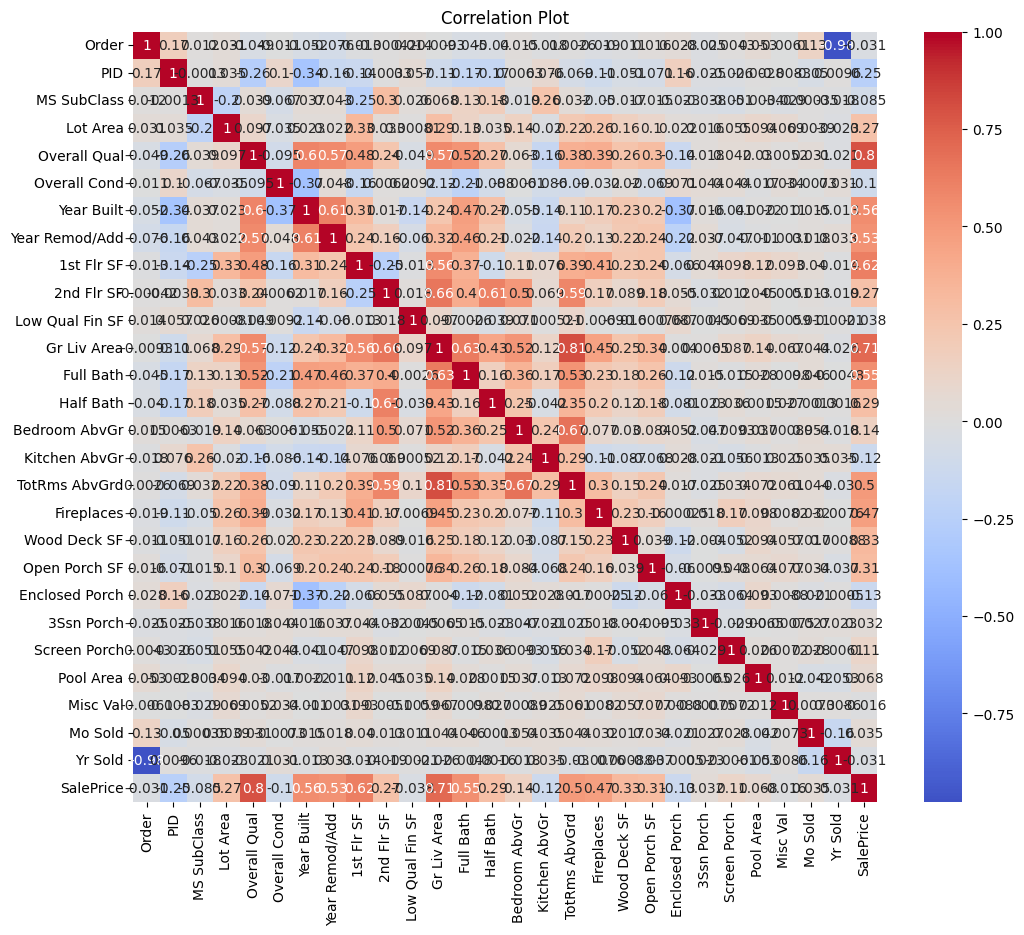

In [34]:
# Solution code
numerical_data = Ames.select_dtypes(include=[np.number]).dropna(axis=1)
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Plot')
plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — correlation heatmap**

**General guidelines**
- Pearson correlation is exploratory — it detects linear relationships, not all redundancy.
- Strong blocks of correlated predictors suggest multicollinearity risk for linear models.
- Correlation with the target (`SalePrice`) hints at predictive features but does not prove causality.

**This notebook's output**
- Heatmap shows several strongly correlated numeric features.
- `SalePrice` correlates with living-area and quality-related variables.
- Redundant-looking feature groups motivate the rank and VIF checks in later sections.

</div>

## 3. Multicollinearity

### 3.1 Matrix rank and redundant features

As an initial check for strong multicollinearity, we compare two numbers:

1. the number of numerical features in the dataset;
2. the **matrix rank** of those features.

To calculate the rank, we first turn the numerical part of the dataset into a matrix. In this matrix, each row is a house and each column is a numerical feature.

The **rank** tells us how many columns contain unique, non-repeated information. More formally, it is the maximum number of columns that are **linearly independent**.

A column is linearly independent if it cannot be recreated exactly by adding, subtracting, or multiplying the other columns. For example, if:

```text
C = A + B
```

then column `C` is not independent. It does not add a new dimension of information, because it can be calculated exactly from `A` and `B`.

So if the dataset has 28 numerical features but the matrix rank is only 27, this means that at least one numerical feature is redundant. In other words, at least one feature can be recreated as a linear combination of other features. This is called **perfect multicollinearity**.

In [35]:
# Select numerical columns without missing values
numerical_data = Ames.select_dtypes(include=[np.number]).dropna(axis=1)
 
# Calculate the matrix rank
rank = np.linalg.matrix_rank(numerical_data.values)
 
# Number of features
num_features = numerical_data.shape[1]
 
# Print the rank and the number of features
print(f"Numerical features without missing values: {num_features}")
print(f"Rank: {rank}")

Numerical features without missing values: 28
Rank: 27


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: matrix rank output**

The output shows:

```text
Numerical features without missing values: 28
Rank: 27
```

**What exactly is in the matrix?**

The matrix is the raw numerical data table after selecting numerical columns and dropping columns with missing values. Each row is one house. Each column is one numerical feature. Each cell contains the actual observed value of that feature for that house.

For example, one row might contain values like:

```text
Gr Liv Area = 1710
1st Flr SF = 856
2nd Flr SF = 854
Low Qual Fin SF = 0
SalePrice = 208500
```

**How is the rank calculated from this matrix?**

`np.linalg.matrix_rank()` uses linear algebra to ask: how many columns add genuinely new information?

Conceptually, it tries to find the largest set of columns where none of the columns can be rebuilt exactly from the others. If a column can be calculated from other columns, it does not increase the rank.

A small example:

```text
A = [1, 2, 3]
B = [10, 20, 30]
C = A + B = [11, 22, 33]
```

Here there are three columns: `A`, `B`, and `C`. But `C` is exactly `A + B`, so the matrix has only two independent columns. Its rank is 2, not 3.

The same idea is applied to the Ames numerical data matrix. The calculation is done on all rows at once, not row by row. It checks whether whole columns are independent from the other columns.

**How to read the rank result**

There are 28 numerical columns, but the rank is only 27. This means the 28 columns do not all add independent information. At least one column can be calculated exactly from other columns.

The rank check tells us that exact redundancy exists. It does not yet tell us which variables are involved. The next code cell identifies the redundant feature group.

</div>

In [36]:
# From https://machinelearningmastery.com/detecting-and-overcoming-perfect-multicollinearity-in-large-datasets/

def find_redundant_features(data):
    """
    Identifies and returns redundant features in a dataset based on matrix rank.
    A feature is considered redundant if removing it does not decrease the rank of the dataset,
    indicating that it can be expressed as a linear combination of other features.

    Parameters:
        data (DataFrame): The numerical dataset to analyze.

    Returns:
        list: A list of redundant feature names.
    """

    # Calculate the matrix rank of the original dataset
    original_rank = np.linalg.matrix_rank(data)
    redundant_features = []

    for column in data.columns:
        # Create a new dataset without this column
        temp_data = data.drop(column, axis=1)
        # Calculate the rank of the new dataset
        temp_rank = np.linalg.matrix_rank(temp_data)

        # If the rank does not decrease, the removed column is redundant
        if temp_rank == original_rank:
            redundant_features.append(column)

    return redundant_features


numerical_data = Ames.select_dtypes(include=[np.number]).dropna(axis=1)
redundant_features = find_redundant_features(numerical_data)
print("Redundant features:", redundant_features)

Redundant features: ['1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area']


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: redundant features from the helper function**

The helper function returns:

```text
['1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area']
```

This does **not** mean that all four variables are useless. It means that these four variables are part of the same exact linear relationship. Together, they contain one duplicated dimension of information.

The function finds this by removing one column at a time. If the rank does not decrease after a column is removed, that column was redundant in the presence of the other columns.

For these four variables, the exact relationship is:

```text
Gr Liv Area = 1st Flr SF + 2nd Flr SF + Low Qual Fin SF
```

So the issue is not one bad column. The issue is the complete set of four columns: if all four are used together in a linear model, one of them repeats information already contained in the other three.

</div>

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**3.1 — TASK**

Can you check and explain how these variables are related?

</div>

In [37]:
# Add your code here

# Hints:
# - Compute `Gr Liv Area` and the sum of `1st Flr SF`, `2nd Flr SF`, `Low Qual Fin SF`.
# - Compare row-wise — are they identical?
# - Report the percentage of rows where they match.


In [38]:
# Solution code
# Calculate the sum of '1stFlrSF', '2ndFlrSF', and 'LowQualFinSF'
Ames['CalculatedGrLivArea'] = Ames['1st Flr SF'] + Ames['2nd Flr SF'] + Ames['Low Qual Fin SF']

# Compare the calculated sum with the existing 'GrLivArea' column to see if they are the same
Ames['IsEqual'] = Ames['Gr Liv Area'] == Ames['CalculatedGrLivArea']

# Output the percentage of rows where the values match
match_percentage = Ames['IsEqual'].mean() * 100
print(f"Percentage of rows where Gr Liv Area equals the sum of the other three features: {int(match_percentage)}%")

Percentage of rows where Gr Liv Area equals the sum of the other three features: 100%


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: perfect collinearity**

**How to read this**
- If the matrix rank is smaller than the number of columns, at least one variable is an exact combination of other variables.
- This is a problem for interpreting linear regression coefficients.
- Predictions may still be stable, but the separate coefficient values are not easy to trust.

**In this notebook**
- `Gr Liv Area` is exactly equal to the sum of `1st Flr SF`, `2nd Flr SF`, and `Low Qual Fin SF` for 100% of the rows.
- This means `Gr Liv Area` repeats information that is already present in the floor-area variables.
- That is why the rank check found 27 independent dimensions for 28 numerical features.

</div>

Having established the redundancy of Gr Liv Area through matrix rank analysis, we now aim to visualize the effects of multicollinearity on the regression model’s stability and predictive power. For ease, we will limit the number of features (see below).

First we assess the relationship between the features and the target variable.

In [39]:
features = ['Gr Liv Area', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**3.2 — TASK**

Make some basic exploration plots to study the relationship between the features and the target variable.

</div>

In [40]:
# Add your code here

# Hints:
# - Scatter or regression plots of each feature vs `SalePrice`.
# - Use the four floor-area related features from the reduced set.
# - Note linearity and outliers — extrapolation test set has high prices.


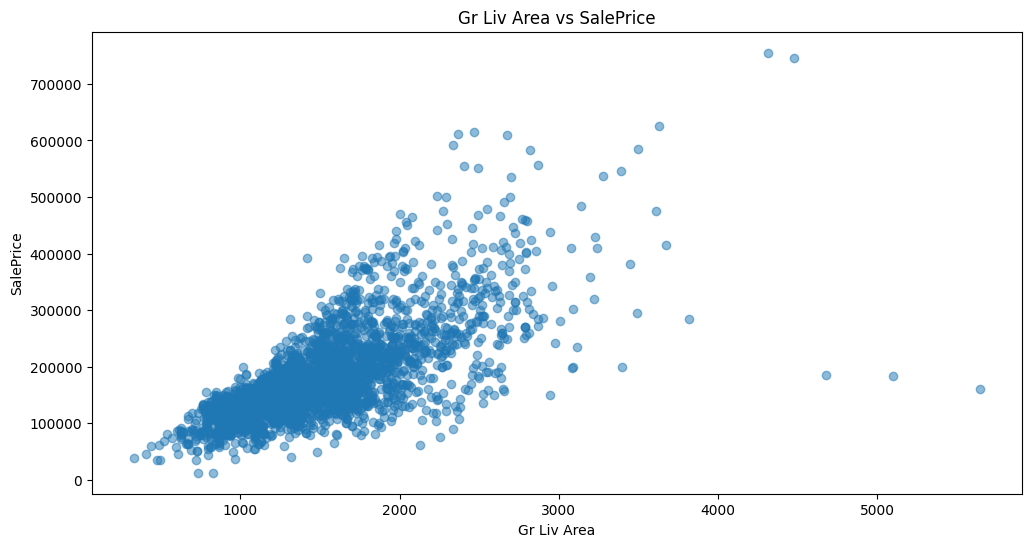

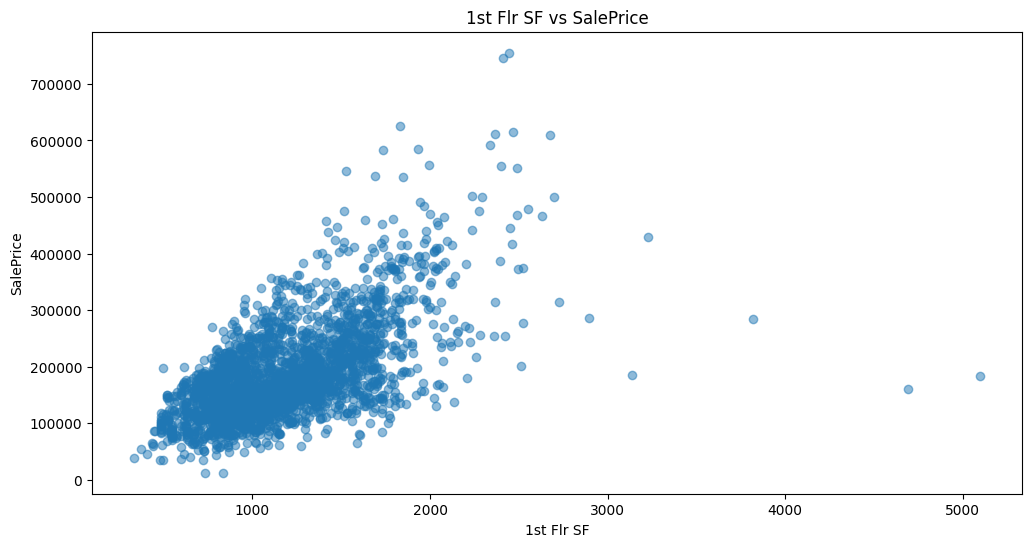

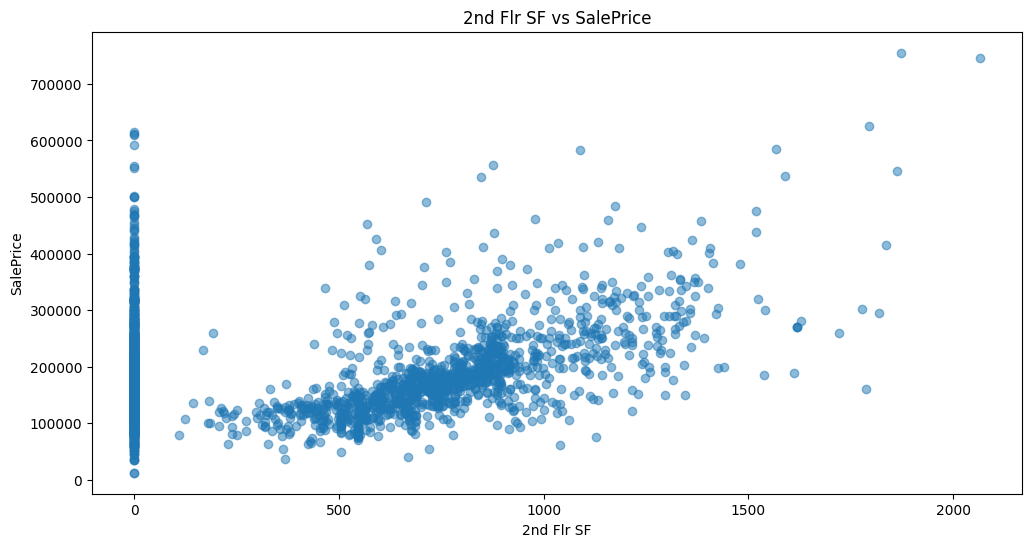

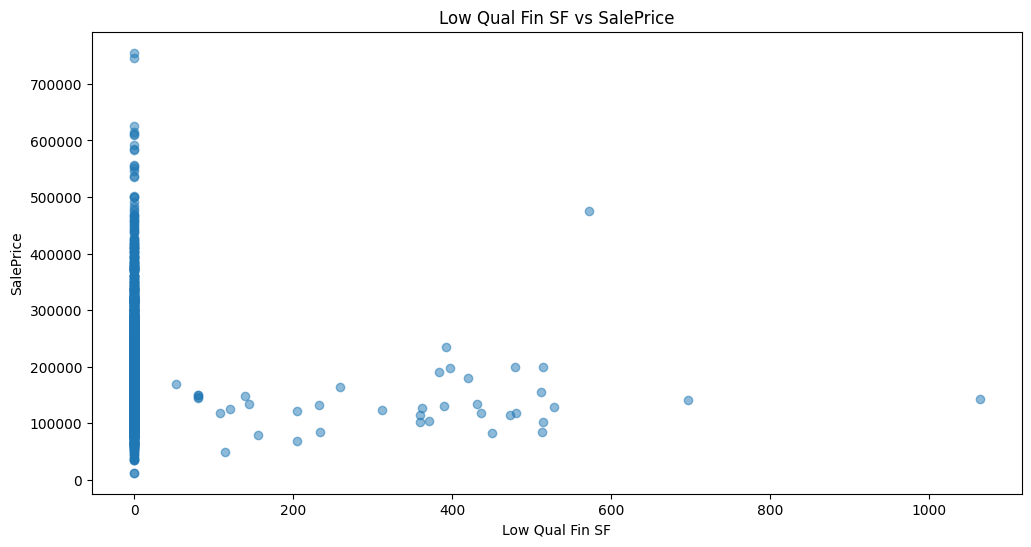

In [41]:
# Solution code

# Make a plot of the features and the target variable

for feature in features:
    plt.figure(figsize=(12, 6))
    plt.scatter(Ames[feature], Ames['SalePrice'], alpha=0.5)
    plt.title(f'{feature} vs SalePrice')
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — feature–target exploratory data analysis**

**General guidelines**
- Visualise linearity before trusting linear regression coefficients.
- Outliers and heteroscedasticity affect both OLS and regularised models.
- Compare slope patterns — collinear features show similar price relationships.

**This notebook's output**
- Scatter plots for `Gr Liv Area`, `1st Flr SF`, `2nd Flr SF`, `Low Qual Fin SF` vs `SalePrice`.
- `Gr Liv Area`, `1st Flr SF`, and `2nd Flr SF` show positive relationships with `SalePrice`; `Low Qual Fin SF` is much sparser and less directly informative.
- These plots motivate the later VIF and Lasso checks, but they do not by themselves prove which one variable should be removed.

</div>

## 4. Training diagnostics

### Validation and training data

In general, training data should be representative of future test data and we should avoid any extrapolation of our model. However, in the following example, besides a normal test split, we intentionally construct a non-representative training set (test_extrapolation) in order to assess its impact.

In [42]:
test_extrapolation = Ames[Ames['SalePrice'] > 500000]
train, test = train_test_split(Ames[Ames['SalePrice'] <= 500000], test_size=0.2, random_state=42)

First we train a LinearRegression model with 5-fold CV and plot the coefficients and performance.

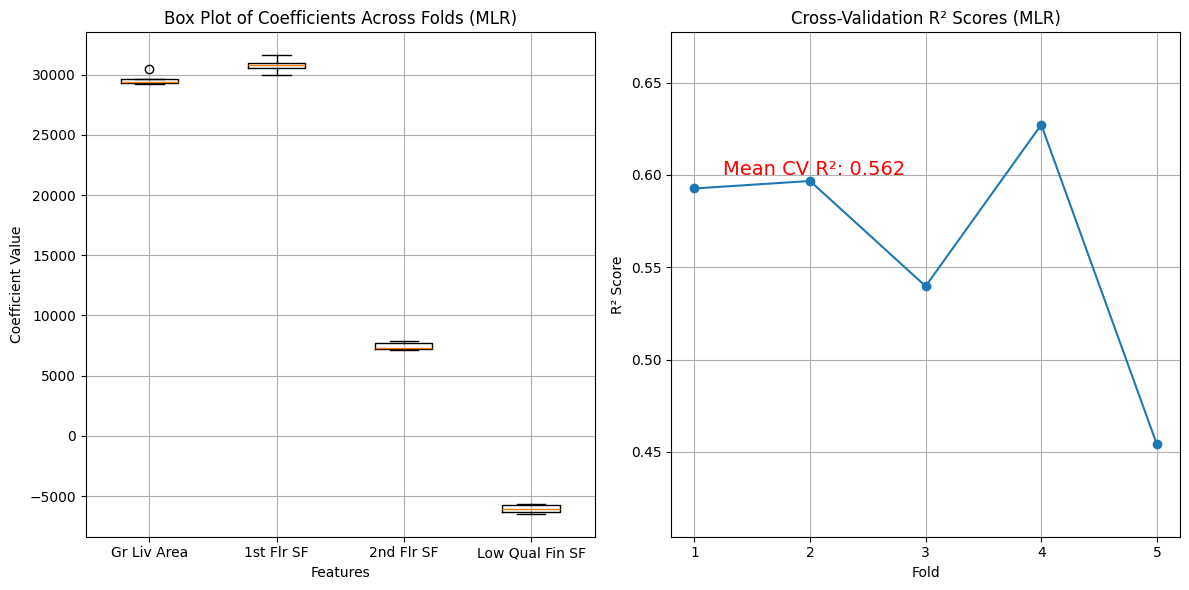

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
X = train[features]
y = train['SalePrice']

# Initialize a K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Collect coefficients and CV scores
coefficients = []
cv_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    coefficients.append(model.coef_)

    # Calculate R^2 score using the model's score method
    score = model.score(X_test_scaled, y_test)
    # print(score)
    cv_scores.append(score)

# Plotting the coefficients
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(np.array(coefficients), tick_labels=features)
plt.title('Box Plot of Coefficients Across Folds (MLR)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.grid(True)

# Plotting the CV scores
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-')  # Adjusted x-axis to start from 1
plt.title('Cross-Validation R² Scores (MLR)')
plt.xlabel('Fold')
plt.xticks(range(1, 6))  # Set x-ticks to match fold numbers
plt.ylabel('R² Score')
plt.ylim(min(cv_scores) - 0.05, max(cv_scores) + 0.05)  # Dynamically adjust y-axis limits
plt.grid(True)

# Annotate mean R² score
mean_r2 = np.mean(cv_scores)
plt.annotate(f'Mean CV R²: {mean_r2:.3f}', xy=(1.25, 0.60), color='red', fontsize=14),

plt.tight_layout()
plt.show()

# Refit the model on all training data

model_full = LinearRegression()

# Scale the features
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

model_full.fit(X_scaled, y)

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: ordinary linear regression across folds**

The left plot shows the fitted coefficients for the four floor-area features across the 5 cross-validation folds. The coefficients are large and not all easy to interpret: for example, `Low Qual Fin SF` receives a negative coefficient, while the other area variables receive positive coefficients.

This does **not** mean that low-quality finished area truly reduces sale price by itself. The safer interpretation is that these floor-area variables overlap strongly. When predictors contain the same information, ordinary linear regression can distribute the effect across them in unstable or unintuitive ways.

The right plot shows that predictive performance also depends on the fold. The mean CV R² is about 0.56, but one fold performs clearly worse than the others. This tells us that the model has some predictive signal, but performance is not perfectly stable across resampled training/test splits.

**Main lesson**

Ordinary linear regression can still produce predictions when predictors are collinear, but the individual coefficients should not be trusted as clean explanations. This is why the next step checks VIF: we want to diagnose whether the predictors are strongly or perfectly explained by each other.

</div>

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.1 — TASK**

Can you check the VIF for the training dataset?

**What is VIF?**

VIF stands for **Variance Inflation Factor**. It is a diagnostic for multicollinearity: it measures how well one predictor variable can be explained by the other predictor variables.

For each feature, VIF fits an auxiliary regression where that feature is treated as the outcome and all the other features are used as predictors. If the other features can predict it very well, the VIF becomes large. This means the feature mostly repeats information already present in the other predictors.

A common rule of thumb:

```text
VIF = 1       no linear overlap with other predictors
VIF > 5       possible multicollinearity warning
VIF > 10      strong multicollinearity warning
VIF = inf     perfect linear dependency
```

</div>

In [44]:
# Add your code here

# Hints:
# - Use the provided `variance_inflation_factor` helper on training features.
# - Build a DataFrame of feature names and VIF values.
# - VIF = ∞ or very large indicates problematic collinearity.


In [45]:
# Solution code

# Code from https://www.kaggle.com/code/carlmcbrideellis/variance-inflation-factor-vif-and-explainability

VIF             = pd.DataFrame()
VIF['feature']  = X_train.columns
VIF['VIF']      = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
# take a look
VIF

/home/vscode/.local/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,Gr Liv Area,inf
1,1st Flr SF,inf
2,2nd Flr SF,inf
3,Low Qual Fin SF,inf


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: VIF on training data**

**How to read this**
- VIF measures how strongly one input variable can be explained by the other input variables.
- A common rule of thumb is that VIF above 10 is a warning sign.
- Infinite VIF means perfect collinearity.
- Compute VIF on the training data, not on the full dataset before splitting.

**In this notebook**
- There are 28 numerical features without missing values, but the matrix rank is 27.
- The four floor-area features all have infinite VIF.
- This matches the earlier result: `Gr Liv Area` is exactly built from the other floor-area variables.
- The linear model can still make predictions, but the individual coefficients are not reliable for interpretation.

</div>

### Ridge regression: stabilising coefficients

VIF showed that the floor-area variables are perfectly collinear. Ordinary linear regression can still make predictions, but the separate coefficients are unstable and hard to interpret.

**Ridge regression** is a classic response to this problem. Ridge keeps all variables in the model, but adds a penalty for large coefficients. This shrinks the coefficients toward zero and usually makes them less extreme across different training samples.

This is different from Lasso:

- **Ridge** shrinks coefficients but usually keeps all features.
- **Lasso** can shrink some coefficients exactly to zero, so it can perform feature selection.

Below we first plot a Ridge coefficient path across several `alpha` values. This helps us choose an illustrative penalty before comparing coefficient stability across folds. Based on the path, `alpha=1000` is used for the fold comparison because the shrinkage is visible enough for teaching. It is not a final tuned hyperparameter.

In this dataset, Ridge does **not** produce a dramatic visible redistribution of the contribution across the floor-area variables. The better teaching point is more modest and more accurate: Ridge shrinks the coefficients and can make them more stable, while usually keeping all correlated predictors in the model. The goal is not to get a higher R², but to ask how the coefficient behaviour changes as regularisation becomes stronger.

<div style="background:#F5F5F5;border-left:5px solid #616161;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**RIDGE DEMONSTRATION**

The code is provided because the important learning point is the interpretation of coefficient stability, not writing the plotting loop from scratch.

Read and run the code in two steps:

1. First inspect the Ridge coefficient path to see how the coefficients change as `alpha` increases.
2. Then compare ordinary linear regression with Ridge using `alpha=1000` across the same 5 cross-validation folds.

The fold comparison uses:

- coefficient boxplots across folds;
- mean and standard deviation of CV R²;
- the standard deviation of each coefficient across folds.

Do not expect this example to show a clear handover of contribution from one variable to another. The main visual lesson is that stronger Ridge penalties gradually shrink coefficients toward zero.

</div>

Ridge coefficient path across alpha values


feature,1st Flr SF,2nd Flr SF,Gr Liv Area,Low Qual Fin SF
alpha,,,,
1,30755.5,7429.6,29577.9,-6043.4
10,30671.7,7422.4,29510.1,-6012.2
100,29858.8,7349.0,28848.7,-5714.8
500,26721.4,7010.5,26239.6,-4652.9
1000,23632.1,6587.8,23580.4,-3732.5
5000,12335.3,4216.6,13048.6,-1289.7
10000,7738.3,2852.3,8380.4,-658.0


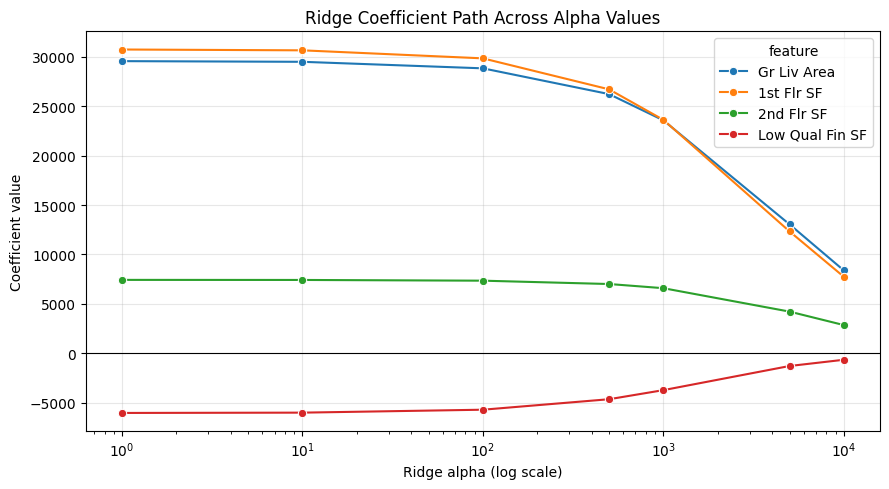

Cross-validation R² summary


,model,mean_r2,sd_r2
0,Ordinary linear regression,0.562,0.068
1,Ridge regression (alpha=1000),0.526,0.037


Coefficient standard deviation across folds


model,Ordinary linear regression,Ridge regression (alpha=1000)
feature,,
1st Flr SF,598.4,385.5
2nd Flr SF,326.8,271.0
Gr Liv Area,505.5,325.5
Low Qual Fin SF,370.9,190.5


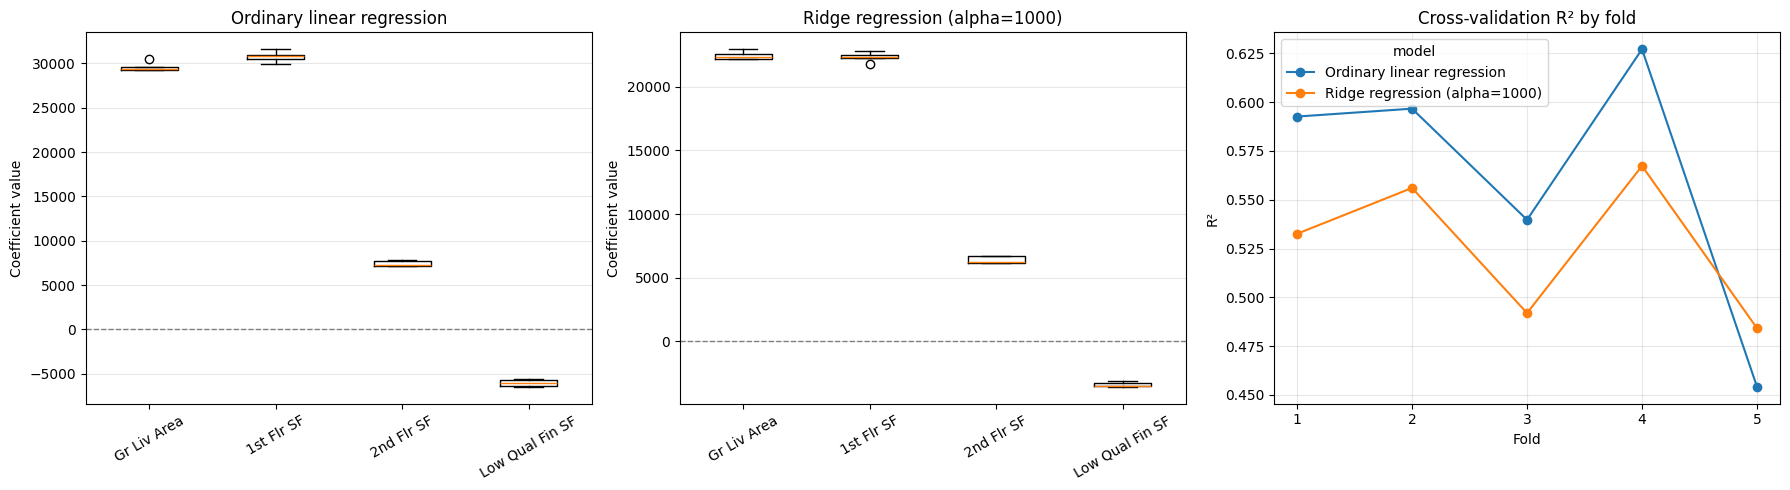

In [64]:
# Ridge demonstration: first inspect the coefficient path, then choose one alpha for CV.

# Coefficient path: show how Ridge changes coefficients as the penalty increases.
ridge_path_alphas = [1, 10, 100, 500, 1000, 5000, 10000]
ridge_path_rows = []

for alpha in ridge_path_alphas:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    model.fit(X, y)

    for feature, coefficient in zip(features, model.named_steps['model'].coef_):
        ridge_path_rows.append({
            'alpha': alpha,
            'feature': feature,
            'coefficient': coefficient,
        })

ridge_path_df = pd.DataFrame(ridge_path_rows)
ridge_path_table = ridge_path_df.pivot(
    index='alpha',
    columns='feature',
    values='coefficient'
)

print('Ridge coefficient path across alpha values')
display(ridge_path_table.round(1))

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=ridge_path_df,
    x='alpha',
    y='coefficient',
    hue='feature',
    marker='o'
)
plt.xscale('log')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Ridge Coefficient Path Across Alpha Values')
plt.xlabel('Ridge alpha (log scale)')
plt.ylabel('Coefficient value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Choose one visible penalty from the path for the fold-stability comparison.
ridge_alpha = 1000
comparison_models = {
    'Ordinary linear regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    f'Ridge regression (alpha={ridge_alpha})': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=ridge_alpha))
    ])
}

kf = KFold(n_splits=5, shuffle=True, random_state=1)
coefficient_rows = []
score_rows = []

for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    for model_name, model in comparison_models.items():
        model.fit(X_train_fold, y_train_fold)
        r2 = model.score(X_test_fold, y_test_fold)
        fitted_model = model.named_steps['model']

        score_rows.append({
            'model': model_name,
            'fold': fold,
            'r2': r2,
        })

        for feature, coefficient in zip(features, fitted_model.coef_):
            coefficient_rows.append({
                'model': model_name,
                'fold': fold,
                'feature': feature,
                'coefficient': coefficient
            })

ridge_scores = pd.DataFrame(score_rows)
ridge_coefficients = pd.DataFrame(coefficient_rows)

score_summary = (
    ridge_scores
    .groupby('model')
    .agg(mean_r2=('r2', 'mean'), sd_r2=('r2', 'std'))
    .reset_index()
)

coefficient_stability = (
    ridge_coefficients
    .groupby(['model', 'feature'])['coefficient']
    .std()
    .reset_index(name='coefficient_sd')
    .pivot(index='feature', columns='model', values='coefficient_sd')
)

print('Cross-validation R² summary')
display(score_summary.round(3))

print('Coefficient standard deviation across folds')
display(coefficient_stability.round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes[:2], comparison_models.keys()):
    data = [
        ridge_coefficients.query('model == @model_name and feature == @feature')['coefficient']
        for feature in features
    ]
    ax.boxplot(data, tick_labels=features)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_title(model_name)
    ax.set_ylabel('Coefficient value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

r2_by_fold = ridge_scores.pivot(index='fold', columns='model', values='r2')
r2_by_fold.plot(marker='o', ax=axes[2])
axes[2].set_title('Cross-validation R² by fold')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('R²')
axes[2].set_xticks(range(1, 6))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: Ridge and coefficient stability**

**How to read this**
- Start with the coefficient path. As `alpha` increases, Ridge gradually shrinks all coefficients toward zero instead of making a hard one-variable selection.
- Then inspect the CV R² summary for the selected `alpha=1000`. This shows the prediction trade-off of using a stronger Ridge penalty.
- Finally, compare the coefficient boxplots and coefficient standard deviations across folds. Smaller spread means the coefficient is more stable across folds.

**In this notebook**
- Ridge is not mainly used to remove variables. It is used to make coefficient estimates less extreme when predictors are strongly correlated.
- `alpha=1000` is chosen from the coefficient path because it makes shrinkage visible enough for teaching. It is not a final tuned hyperparameter.
- With `alpha=1000`, the mean CV R² is lower than ordinary linear regression in this run, about 0.526 versus 0.562. This shows the trade-off: stronger regularisation gives clearer shrinkage but weaker prediction.
- Ridge still does not solve the question of which floor-area variable is "the real one". It keeps the correlated variables in the model and shrinks their coefficients, instead of choosing only one.

**Connection to Lasso**

The next section uses Lasso. Lasso answers a different question: can we simplify the model by shrinking one or more coefficients all the way to zero? That makes Lasso useful for feature selection, while Ridge is more about coefficient stabilisation.

</div>

Ridge showed one way to handle multicollinearity: keep all variables, but shrink the coefficients to make them more stable. Lasso regression takes a different approach.

Lasso can simplify the model because it penalizes coefficient size and can set some coefficients exactly to zero. This makes it useful as a feature-selection tool when predictors are highly correlated.

This does **not** mean that Lasso penalizes variables because they are strongly correlated with the target variable, `SalePrice`. A variable can be highly correlated with the target and still be useful. The penalty is applied to the **coefficient values** that the model chooses.

In a linear model, the prediction is built by multiplying each input variable by a coefficient, often called a beta coefficient:

```text
predicted SalePrice = intercept + beta_1 * feature_1 + beta_2 * feature_2 + ...
```

So a model coefficient is the number that tells the model how strongly to use one input variable when predicting the output variable. A large absolute coefficient means the model is using that feature strongly: a change in that feature leads to a large change in the predicted `SalePrice`, all else being equal. Because this notebook scales the features before fitting Lasso, the coefficients are easier to compare: a larger absolute coefficient means the model relies more strongly on that feature after putting the inputs on a comparable scale.

Ordinary Least Squares regression chooses the beta coefficients that minimize the residual sum of squares (RSS), the difference between the observed target values and the model's predictions:

```text
training objective = RSS
```

Lasso changes the training objective. It still wants a small RSS, but it also adds a penalty for using large beta coefficients:

```text
Lasso objective = RSS + alpha * (|beta_1| + |beta_2| + ... + |beta_p|)
```

This means Lasso balances two goals during training: make accurate predictions and keep the absolute coefficient values small. Larger `alpha` means the coefficient penalty matters more, so the model shrinks coefficients more strongly. Smaller `alpha` means the model behaves more like ordinary least squares.

If two predictors contain similar information, Lasso often keeps one with a non-zero coefficient and shrinks the other toward, or exactly to, zero. This is why Lasso can be useful for feature selection when predictors are highly correlated.

Let’s apply Lasso to our previous example to demonstrate this.


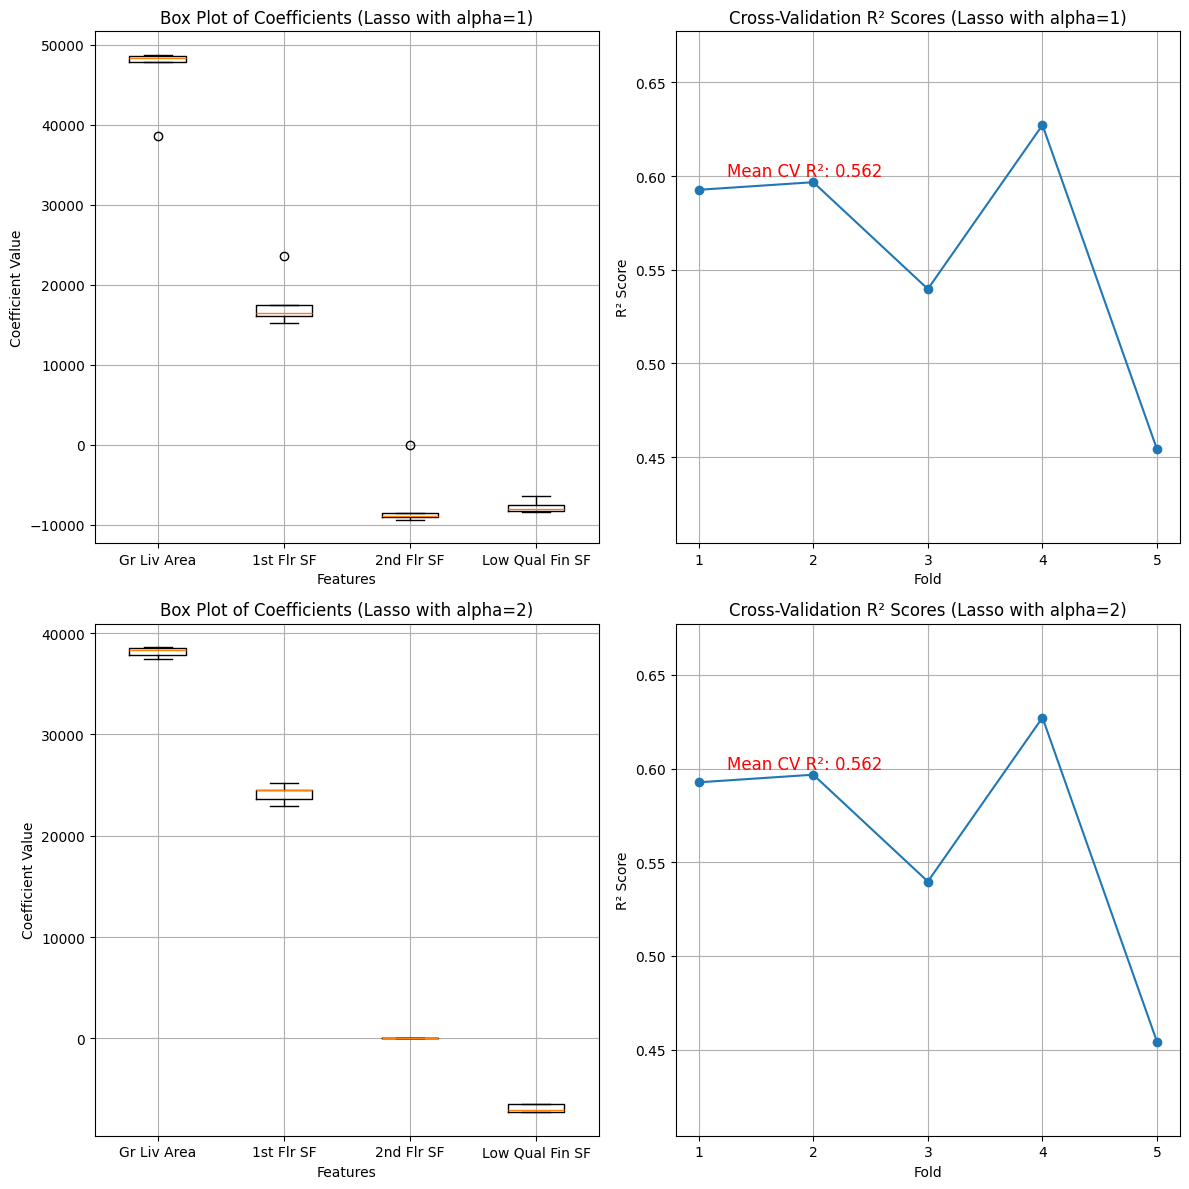

In [47]:
# Initialize a K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Prepare to collect results
results = {}

for alpha in [1, 2]:  # Loop through both alpha values
    coefficients = []
    cv_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Initialize and fit the Lasso regression model
        lasso_model = Lasso(alpha=alpha, max_iter=100000)
        lasso_model.fit(X_train_scaled, y_train)
        coefficients.append(lasso_model.coef_)

        # Calculate R^2 score using the model's score method
        score = lasso_model.score(X_test_scaled, y_test)
        cv_scores.append(score)

    results[alpha] = (coefficients, cv_scores)

# Plotting the results
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
alphas = [1, 2]

for i, alpha in enumerate(alphas):
    coefficients, cv_scores = results[alpha]

    # Plotting the coefficients
    axes[i, 0].boxplot(np.array(coefficients), tick_labels=features)
    axes[i, 0].set_title(f'Box Plot of Coefficients (Lasso with alpha={alpha})')
    axes[i, 0].set_xlabel('Features')
    axes[i, 0].set_ylabel('Coefficient Value')
    axes[i, 0].grid(True)

    # Plotting the CV scores
    axes[i, 1].plot(range(1, 6), cv_scores, marker='o', linestyle='-')
    axes[i, 1].set_title(f'Cross-Validation R² Scores (Lasso with alpha={alpha})')
    axes[i, 1].set_xlabel('Fold')
    axes[i, 1].set_xticks(range(1, 6))
    axes[i, 1].set_ylabel('R² Score')
    axes[i, 1].set_ylim(min(cv_scores) - 0.05, max(cv_scores) + 0.05)
    axes[i, 1].grid(True)
    mean_r2 = np.mean(cv_scores)
    axes[i, 1].annotate(f'Mean CV R²: {mean_r2:.3f}', xy=(1.25, 0.60), color='red', fontsize=12)

plt.tight_layout()
plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: Lasso approach**

**How to read this**
- Lasso is a regularised linear regression model. It adds a penalty for large coefficient values.
- The penalty strength is controlled by `alpha`. A larger `alpha` means stronger shrinkage.
- Unlike Ridge, Lasso can shrink some coefficients exactly to zero. This means Lasso can act as a simple feature-selection method.
- In the left plots, compare the coefficient values across folds. Smaller and more stable boxes mean the model is less sensitive to the exact training fold.
- In the right plots, compare the cross-validation R² values. If R² stays similar while one coefficient becomes zero, the removed feature was probably not essential for prediction.

**In this notebook**
- Increasing `alpha` from 1 to 2 makes the coefficients smaller and more stable.
- The coefficient for `2nd Flr SF` moves close to zero, and at the stronger penalty it is almost removed by the model.
- This makes sense because the floor-area variables are strongly related. Part of the information in `2nd Flr SF` is already present in the other floor-area variables.
- The cross-validation R² does not clearly collapse when this coefficient is shrunk. This suggests that removing or down-weighting `2nd Flr SF` simplifies the model without strongly hurting prediction in this example.
- The important lesson is not that Lasso always finds the "true" feature. With correlated predictors, Lasso may choose one variable from a group and shrink another. This is useful for simplification, but coefficient interpretation still needs care.

</div>

Following the insights gained from the Lasso regression, we have refined our model by removing 2nd Flr SF, a feature identified as contributing minimally to the predictive power. This section evaluates the performance and stability of the coefficients in the revised model, using only ['Gr Liv Area', '1st Flr SF', 'Low Qual Fin SF'].

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.2 — ADVANCED TASK**

Fit a new LinearRegression model only using the relevant features. Evaluate again the effect of removing 1 variable on the model coefficients and performance by a 5-fold CV. After CV refit the model on the full training data and assign it to `model_reduced`.

</div>

In [48]:
# Add your code here

# Hints:
# - Use `features_reduced = ['Gr Liv Area', '1st Flr SF', 'Low Qual Fin SF']` (drop `2nd Flr SF`).
# - Repeat the manual CV loop from the full model.
# - Assign final fitted model to `model_reduced`.


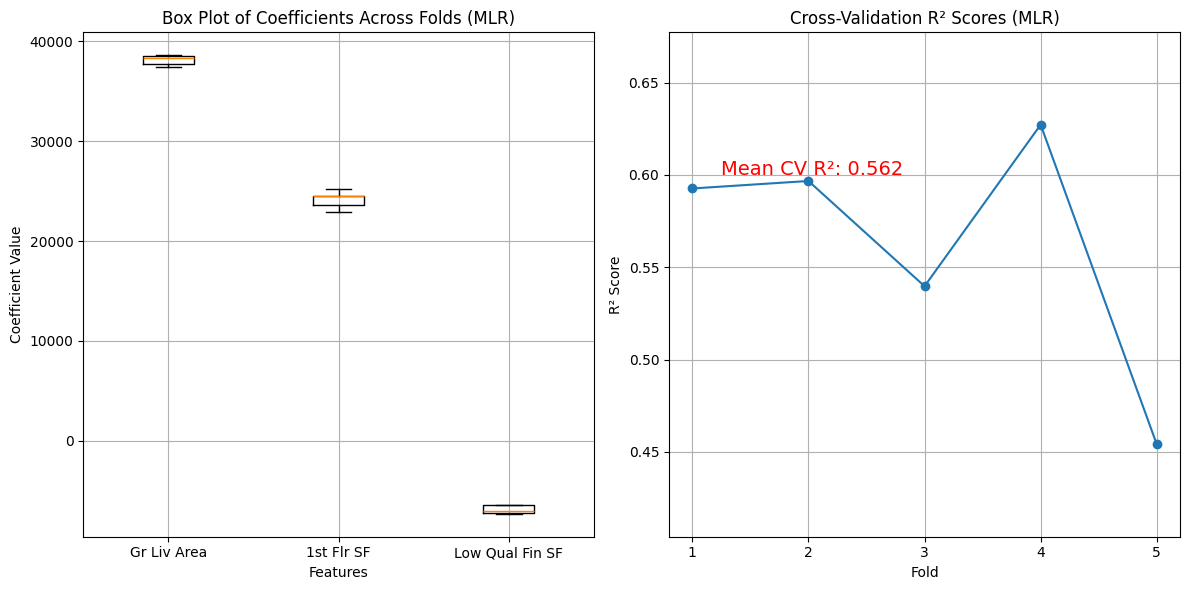

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
# Solution code
features_reduced = ['Gr Liv Area', '1st Flr SF', 'Low Qual Fin SF'] # Remove '2ndFlrSF' after running Lasso
X_reduced = train[features_reduced]
y = train['SalePrice']

# Initialize a K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Collect coefficients and CV scores
coefficients = []
cv_scores = []

for train_index, test_index in kf.split(X_reduced):
    X_train, X_test = X_reduced.iloc[train_index], X_reduced.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    coefficients.append(model.coef_)

    # Calculate R^2 score using the model's score method
    score = model.score(X_test_scaled, y_test)
    # print(score)
    cv_scores.append(score)

# Plotting the coefficients
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(np.array(coefficients), tick_labels=features_reduced)
plt.title('Box Plot of Coefficients Across Folds (MLR)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.grid(True)

# Plotting the CV scores
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-')  # Adjusted x-axis to start from 1
plt.title('Cross-Validation R² Scores (MLR)')
plt.xlabel('Fold')
plt.xticks(range(1, 6))  # Set x-ticks to match fold numbers
plt.ylabel('R² Score')
plt.ylim(min(cv_scores) - 0.05, max(cv_scores) + 0.05)  # Dynamically adjust y-axis limits
plt.grid(True)

# Annotate mean R² score
mean_r2 = np.mean(cv_scores)
plt.annotate(f'Mean CV R²: {mean_r2:.3f}', xy=(1.25, 0.60), color='red', fontsize=14),

plt.tight_layout()
plt.show()

# Refit
model_reduced = LinearRegression()
scaler_reduced = StandardScaler()
X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)
model_reduced.fit(X_reduced_scaled, y)


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: reduced linear model**

**How to read this**
- If two variables carry nearly the same information, removing one of them can make the model easier to explain.
- The goal here is not to make the highest possible score. The goal is to get a simpler model with similar predictive behaviour.
- Cross-validation helps us check whether the reduced model is still stable.

**In this notebook**
- The reduced model uses `Gr Liv Area`, `1st Flr SF`, and `Low Qual Fin SF`.
- `2nd Flr SF` is removed because Lasso suggested that it adds little extra information.
- The 5-fold CV plots look similar to the four-feature model.
- The reduced model is then refit on all training data so it can be tested in the next section.

</div>

## 5. Test evaluation

### 5.1 Standard vs extrapolation test sets

We evaluated models using cross-validation. We now assess performance on held-out test sets that were not used during training or validation.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**5.1 — ADVANCED TASK**

Evaluate the full and reduced linear model on both test sets (`test` and `test_extrapolation`).

Do you expect any differences in predictions when the model has been suffering from multicollinearity or not?

</div>

In [50]:
# Add your code here

# Hints:
# - Predict `SalePrice` on `test` and `test_extrapolation` with `model_full` and `model_reduced`.
# - Report R² (and/or RMSE) on each set.
# - Compare full vs reduced — prediction vs interpretation trade-off.


test: R² = 0.532
test_extrapolation: R² = -10.311


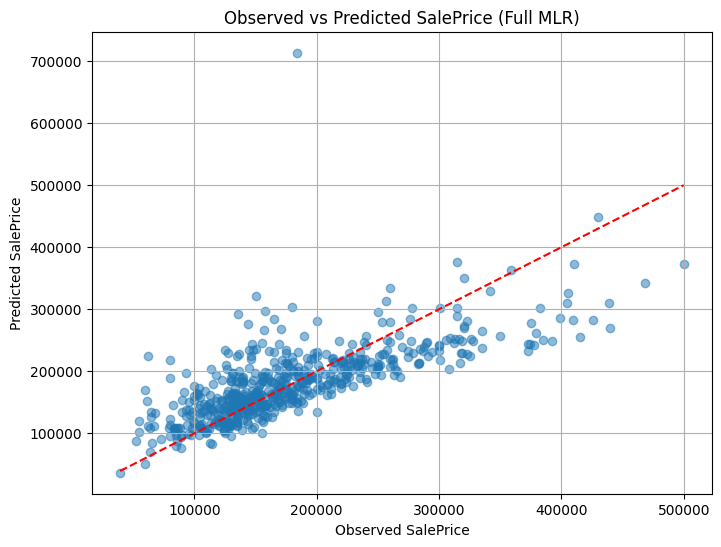

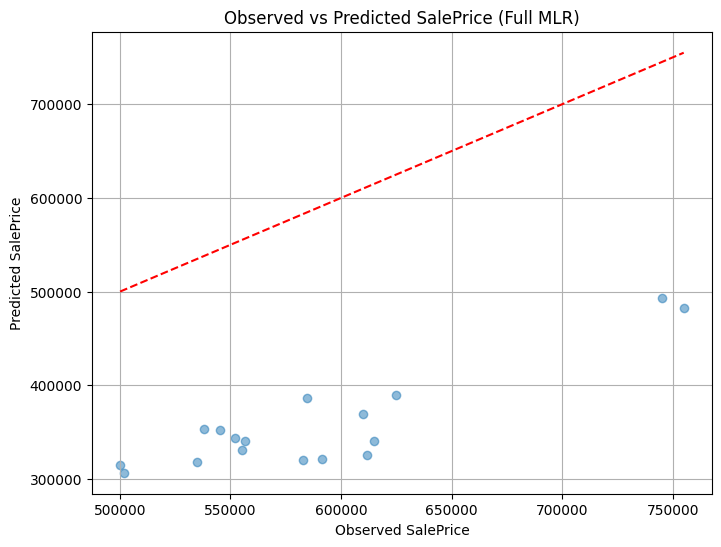

In [51]:
# Solution code

# Full model on test and extrapolation data

for data_name, test_data in {"test": test, "test_extrapolation": test_extrapolation}.items():
    
    # Scale the features of the test data
    test_data_scaled = scaler_full.transform(test_data[features])

    pred_full = model_full.predict(test_data_scaled)
    score = model_full.score(test_data_scaled, test_data['SalePrice'])
    print(f"{data_name}: R² = {score:.3f}")
    # Solution code
    # Obs vs predicted plot
    plt.figure(figsize=(8, 6))
    plt.scatter(test_data['SalePrice'], pred_full, alpha=0.5)
    plt.plot([test_data['SalePrice'].min(), test_data['SalePrice'].max()],
            [test_data['SalePrice'].min(), test_data['SalePrice'].max()],
            color='red', linestyle='--')  # Add a reference line for perfect predictions
    plt.title('Observed vs Predicted SalePrice (Full MLR)')
    plt.xlabel('Observed SalePrice')
    plt.ylabel('Predicted SalePrice')
    plt.grid(True)

test: R² = 0.532
test_extrapolation: R² = -10.311


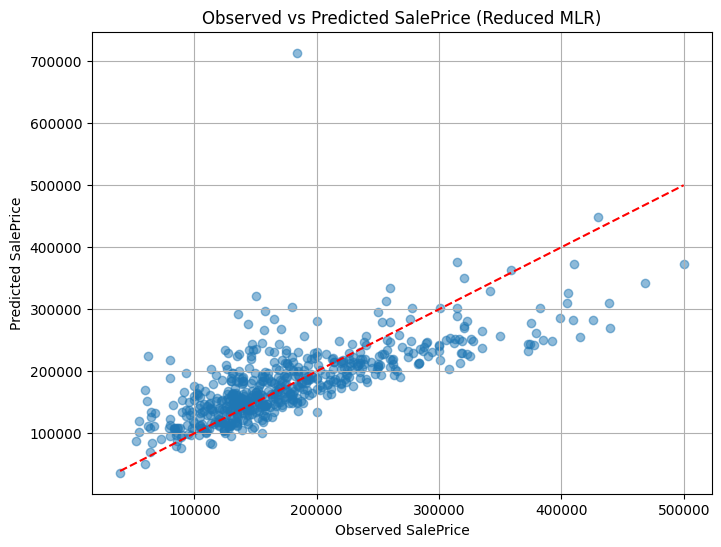

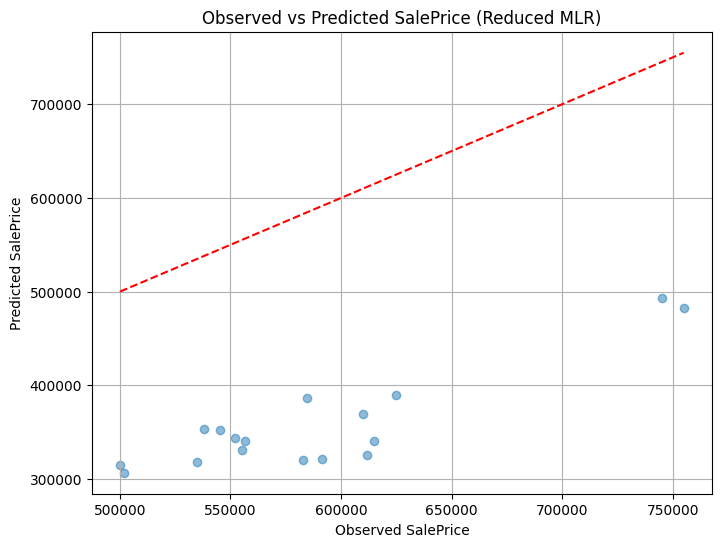

In [52]:
# Solution code

# Reduced model on test and extrapolation data

for data_name, test_data in {"test": test, "test_extrapolation": test_extrapolation}.items():
    
    # Scale the features of the test data
    test_data_scaled = scaler_reduced.transform(test_data[features_reduced])

    pred_reduced = model_reduced.predict(test_data_scaled)
    score = model_reduced.score(test_data_scaled, test_data['SalePrice'])
    print(f"{data_name}: R² = {score:.3f}")

    # Obs vs predicted plot
    plt.figure(figsize=(8, 6))
    plt.scatter(test_data['SalePrice'], pred_reduced, alpha=0.5)
    plt.plot([test_data['SalePrice'].min(), test_data['SalePrice'].max()],
            [test_data['SalePrice'].min(), test_data['SalePrice'].max()],
            color='red', linestyle='--')  # Add a reference line for perfect predictions
    plt.title('Observed vs Predicted SalePrice (Reduced MLR)')
    plt.xlabel('Observed SalePrice')
    plt.ylabel('Predicted SalePrice')
    plt.grid(True)

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: two test sets**

**How to read this**
- Multicollinearity mainly makes the coefficients difficult to interpret.
- It does not always hurt prediction, especially when the test data look like the training data.
- An extrapolation set is different. It asks the model to predict in a part of the data space where it has little training experience.

**In this notebook**
- On the standard test set, both the full and reduced model have R² about 0.532.
- On the extrapolation set with expensive houses (`SalePrice > 500k`), both models fail badly: R² is about -10.3.
- Removing one collinear feature does not change the predictions here.
- The main problem on the extrapolation set is distribution shift, not multicollinearity by itself.

</div>

## 6. Lasso regularisation and synthetic features

### Extension: synthetic correlated features

What happens if we generate many more correlated features? Below we generate synthetic features correlated with `Gr Liv Area`.

#### Generating new features

In [53]:
X_train_new = train[features].copy()
X_test_new = test[features].copy()
X_test_extrapolation_new = test_extrapolation[features].copy()

y_train = train["SalePrice"]
y_test = test["SalePrice"]
y_test_extrapolation = test_extrapolation["SalePrice"]

for i in range(2000):
    noise = np.random.normal(0.8, 1, size=train.shape[0])

    X_train_new[f"synthetic_feature_{i}"] = noise * X_train_new["Gr Liv Area"]

    noise = np.random.normal(0.8, 1, size=test.shape[0])

    X_test_new[f"synthetic_feature_{i}"] = noise * X_test_new["Gr Liv Area"]

    #noise = np.random.normal(0.8, 1, size=test_extrapolation.shape[0])

    #X_test_extrapolation_new[f"synthetic_feature_{i}"] = noise * X_test_extrapolation_new["Gr Liv Area"]


/tmp/ipykernel_36820/4624736.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_new[f"synthetic_feature_{i}"] = noise * X_train_new["Gr Liv Area"]
/tmp/ipykernel_36820/4624736.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_new[f"synthetic_feature_{i}"] = noise * X_test_new["Gr Liv Area"]


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: how the synthetic correlated features are generated**

The goal of this extension is to create an overloaded dataset: many input variables, but not much genuinely new information.

The code starts with the original floor-area features, including `Gr Liv Area`. Then it creates 2000 new variables. Each synthetic feature is generated from the same base variable:

```text
synthetic_feature_i = random_noise * Gr Liv Area
```

The random noise values are drawn from a normal distribution with mean `0.8` and standard deviation `1`. This means every synthetic feature is a noisy, rescaled version of `Gr Liv Area`.

So the synthetic variables are not independent new housing measurements. They are artificial copies that partly repeat the same signal. This creates a realistic pitfall: a model sees thousands of predictors, but many of them are correlated echoes of one original variable.

This is useful for demonstrating overfitting. A flexible model can find accidental patterns in these noisy copies that fit the training data but do not generalise well to unseen test data.

</div>

#### Correlation matrix of synthetic features

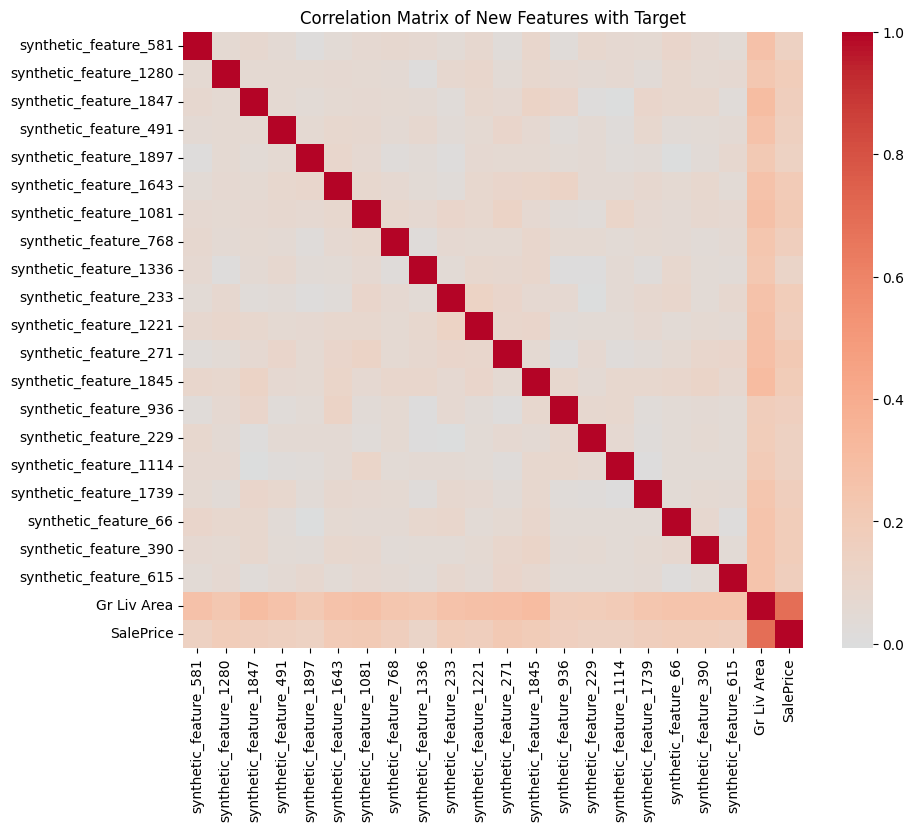

In [54]:
# Make heatmap of the correlation matrix for the new features (X_train_new) (we only select 20 random features) and with target variable (y_train)
train_sampled = X_train_new.copy()
train_sampled = train_sampled.sample(n=20, axis=1, random_state=42)
# Always keep Gr Liv Area"
train_sampled['Gr Liv Area'] = X_train_new['Gr Liv Area']
train_sampled[y_train.name] = y_train
plt.figure(figsize=(10, 8))
sns.heatmap(train_sampled.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of New Features with Target')
plt.show()

#### Scale the features

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)
#X_test_extrapolation_scaled = scaler.transform(X_test_extrapolation_new)

#### Linear model on synthetic features

Train R²: 0.9632
Test  R²: -2.1817


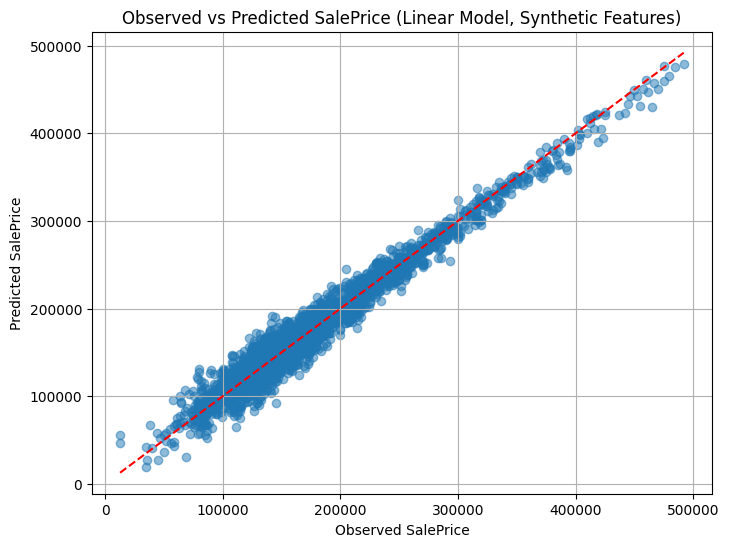

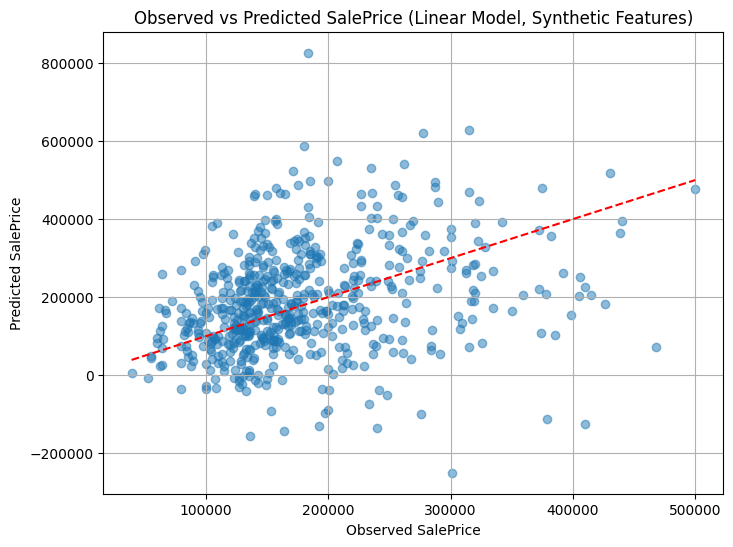

In [56]:
# Fit a linear model on the training data with synthetic features
model_synthetic = LinearRegression()
model_synthetic.fit(X_train_scaled, y_train)

# Predict on train and test
pred_train = model_synthetic.predict(X_train_scaled)
pred_test = model_synthetic.predict(X_test_scaled)

# Optional: print R² scores
print(f"Train R²: {model_synthetic.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {model_synthetic.score(X_test_scaled, y_test):.4f}")

# Observed vs predicted plot (train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Linear Model, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

# Observed vs predicted plot (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Linear Model, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: unregularised linear model on synthetic features**

The unregularised linear model is very susceptible to overfitting when many noisy correlated features are added.

In this run, the model fits the training data very closely:

```text
Train R²: 0.9632
Test  R²: -2.1817
```

This is a severe train-test gap. The training R² looks excellent, but the negative test R² means the model predicts worse than a simple baseline that always predicts the mean test-set `SalePrice`.

The synthetic features do not contain much meaningful new information beyond `Gr Liv Area`. However, because there are 2000 noisy correlated copies, ordinary linear regression can combine them in ways that match accidental patterns in the training data. Those accidental patterns do not generalise to the test data.

This illustrates why cross-validation, a clean test set, and feature selection or regularisation are important when the number of correlated predictors becomes large.

</div>

Can we fix this problem easily with a Lasso regression?

Train R²: 0.9631
Test  R²: -1.9572


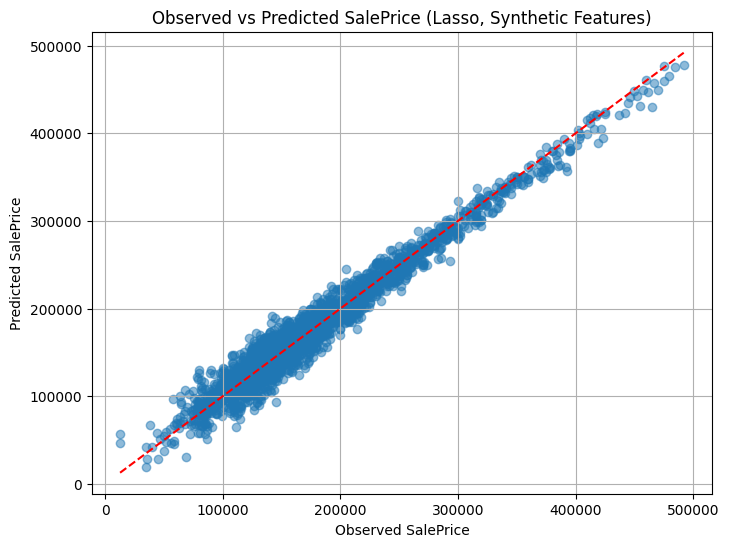

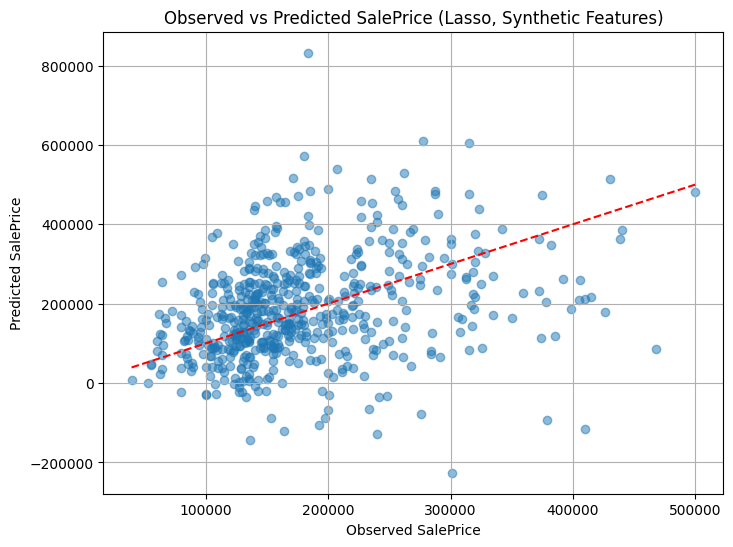

In [57]:
# Fit a Lasso model on the training data with synthetic features
lasso_model = Lasso(alpha=2, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

# Predict on train and test
pred_train = lasso_model.predict(X_train_scaled)
pred_test = lasso_model.predict(X_test_scaled)

# Print R² scores
print(f"Train R²: {lasso_model.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {lasso_model.score(X_test_scaled, y_test):.4f}")


# Observed vs predicted plot (train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Lasso, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

# Observed vs predicted plot (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Lasso, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: manually chosen Lasso on synthetic features**

The manually chosen Lasso model with `alpha=2` still overfits heavily:

```text
Train R²: 0.9631
Test  R²: -1.9572
```

This is only a small improvement over the unregularised linear model. The model still fits the training data very closely but fails badly on the test data.

This does **not** mean that regularisation is useless. It means that the penalty strength was not chosen carefully. With thousands of noisy correlated features, a weak penalty can still leave too much flexibility in the model.

A common pitfall is to try several `alpha` values and then report the one that works best on the test set. That would leak test-set information into model selection. The better approach is to tune `alpha` with cross-validation on the training data, then evaluate only once on the untouched test data.

</div>

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.1 — TASK**

Tune the alpha in the lasso regression. Make a grid with custom values (try to limit to e.g. ±20 values). For tuning use `LassoCV()`. Since we will use CV, implement scaling in a pipeline. Evaluate on `X_train_new` and `X_test_new`.

</div>

In [58]:
# Add your code here

# Hints:
# - Build `Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(...))])`
# - Pass a custom `alphas` grid (~20 values, log-spaced)
# - Fit on `X_train_new`, score train and test R²; count non-zero coefficients
# lasso_cv_model = Pipeline([


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


Best alpha: 1000.000000
Train R²: 0.7636
Test  R²: 0.4890
Non-zero coefficients: 461 / 2004


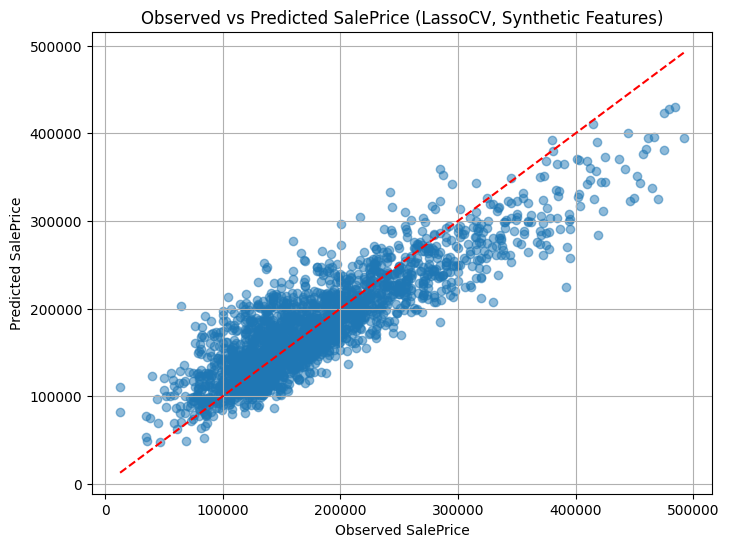

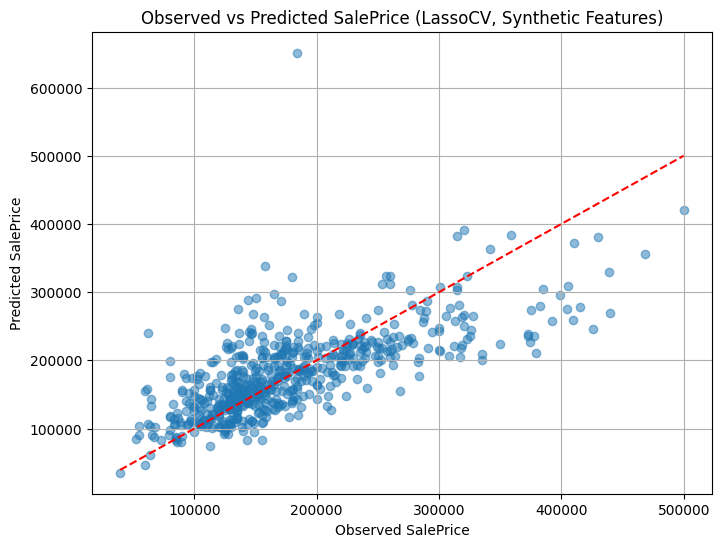

In [59]:
# Solution code

lasso_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        alphas=np.logspace(start=-4, stop=3, num=20),
        cv=5,
        max_iter=50000,
        random_state=42
    ))
])


lasso_cv_model.fit(X_train_new, y_train)

# Show the fitted scikit-learn pipeline diagram in the notebook.
display(lasso_cv_model)

lasso_step = lasso_cv_model.named_steps["lasso"]
lasso_cv_model.alpha_ = lasso_step.alpha_
lasso_cv_model.coef_ = lasso_step.coef_

# Predict on train and test
pred_train = lasso_cv_model.predict(X_train_new)
pred_test = lasso_cv_model.predict(X_test_new)

# Print performance
print(f"Best alpha: {lasso_cv_model.alpha_:.6f}")
print(f"Train R²: {lasso_cv_model.score(X_train_new, y_train):.4f}")
print(f"Test  R²: {lasso_cv_model.score(X_test_new, y_test):.4f}")

# Inspect sparsity
coef = lasso_cv_model.coef_
print(f"Non-zero coefficients: {(coef != 0).sum()} / {len(coef)}")

# Observed vs predicted plot (train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (LassoCV, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

# Observed vs predicted plot (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (LassoCV, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: LassoCV tuning**

**What is the `Pipeline` object here?**
- `lasso_cv_model` is a scikit-learn `Pipeline`.
- The first step is `StandardScaler`, called `scaler`.
- The second step is `LassoCV`, called `lasso`.
- We explicitly call `display(lasso_cv_model)` after fitting, so Jupyter shows the fitted pipeline as a visual diagram.
- That diagram is only a readable summary of the model steps.

**How do we use it?**
- `lasso_cv_model.fit(X_train_new, y_train)` fits the scaler and then fits `LassoCV` on the scaled features.
- `lasso_cv_model.predict(X_test_new)` applies the same scaling to the test data and then predicts `SalePrice`.
- `lasso_cv_model.named_steps["lasso"]` gives access to the fitted LassoCV step inside the pipeline. This is why the solution can read the selected `alpha_` and the fitted coefficients.

**How to read the Lasso result**
- Lasso adds a penalty that makes many coefficients smaller.
- Some coefficients can become exactly zero. This is why Lasso can also act as feature selection.
- The strength of the penalty is controlled by `alpha`.
- Choose `alpha` with cross-validation. Do not tune it by repeatedly looking at the test set.

**In this notebook**
- The selected alpha is 1000, which is the largest value in the tested grid. This means the grid may be too narrow; a larger upper bound could be worth trying.
- The LassoCV model has train R² about 0.7636 and test R² about 0.4890.
- It keeps 461 of the 2004 coefficients non-zero.
- This is much better than both the unregularised linear model and the manually chosen Lasso on the same synthetic features. Those models had very high train R² but strongly negative test R².
- LassoCV reduces overfitting a lot because cross-validation selects a much stronger penalty. However, it still leaves a sizeable train-test gap and many non-zero synthetic coefficients, so it is an improvement rather than a complete solution.

</div>

#### Random Forest on synthetic features

LassoCV improved the synthetic-feature problem substantially, but the selected alpha was at the upper edge of the grid and many synthetic coefficients remained non-zero. To finish, we evaluate a Random Forest on this overloaded feature set and compare its train and test performance.

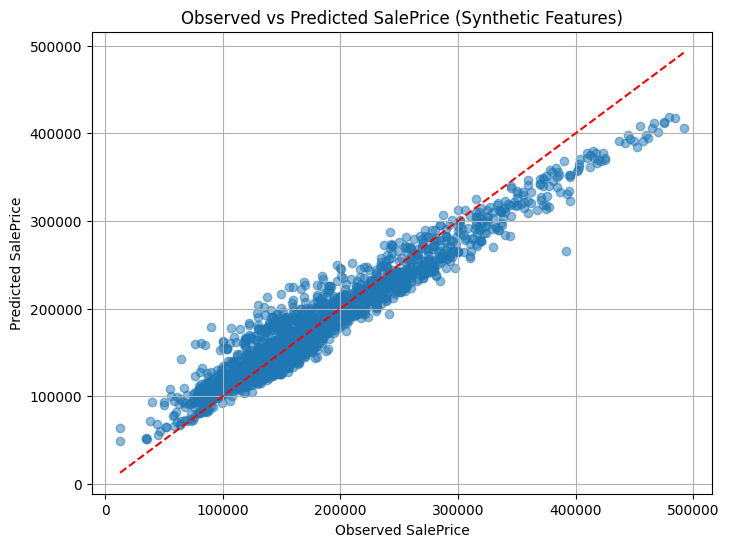

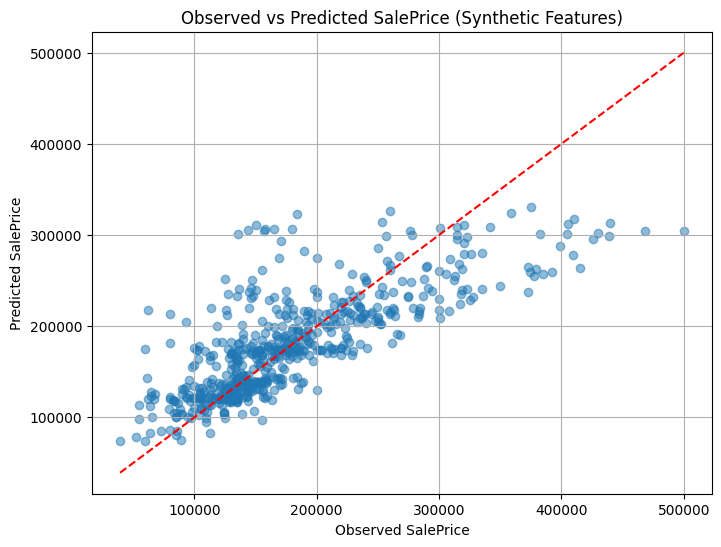

In [60]:
# Fit a random forest model on the training data with synthetic features
model_synthetic = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
model_synthetic.fit(X_train_scaled, y_train)

# Plot performance on train and test data
pred_train = model_synthetic.predict(X_train_scaled)
pred_test = model_synthetic.predict(X_test_scaled)

# Obs vs predicted plot for training data x_train_new and y_train_new
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')  # Add a reference line for perfect predictions
plt.title('Observed vs Predicted SalePrice (Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)

# Apply the model to the test data and plot performance
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
            color='red', linestyle='--')  # Add a reference line for perfect predictions
plt.title('Observed vs Predicted SalePrice (Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)

In [61]:
# Print R² scores
print(f"Train R²: {model_synthetic.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {model_synthetic.score(X_test_scaled, y_test):.4f}")

Train R²: 0.9179
Test  R²: 0.6036


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: Random Forest on synthetic features**

The Random Forest also shows a train-test gap:

```text
Train R²: 0.9179
Test  R²: 0.6036
```

This means there is still some overfitting, but the test performance is much better than the unregularised linear model and the manually chosen Lasso on the synthetic features. It is also better than the LassoCV result in this run.

This reflects the bias-variance trade-off. A flexible model can fit complex patterns in the training data, but too much flexibility can also fit noise. Here, the Random Forest is constrained with `max_depth`, `min_samples_split`, and `min_samples_leaf`, which helps limit the overfitting.

The fitted models tell a useful story: the unregularised linear model and weak Lasso penalty overfit badly; cross-validated Lasso improves generalisation by shrinking many coefficients; the constrained Random Forest performs best here, but still shows a train-test gap.

The main lesson is not that Random Forest is always better. The lesson is that many noisy correlated features can make a simple linear model unstable, regularisation can help, and model choice plus validation are needed to check whether the apparent training performance generalises.

</div>


#### Reproducibility note (splits / LassoCV)

Train–test splits and `LassoCV` use fixed `random_state` where set in the notebook. Exact R² values may differ slightly across library versions; focus on the qualitative patterns (collinearity, extrapolation failure, overfitting with synthetic features).